# 75 - Silver Standard Judge Disagreement Rate

Verifies the "roughly 16%" judge-disagreement figure cited in three places in thesis.tex: the paragraph "The silver standard should be read with caution, not treated as ground truth" in Section 4.1, the active-learning results paragraph, and the "third bias" limitations paragraph. Those sentences describe the share of candidates where the two LLM judges disagreed and the author personally resolved the tie.

This reuses the exact same judging-round list as Notebook 68 (LLM-LLM Cohen's kappa), since the thesis text itself describes Notebook 68 as covering "every judging round run for this thesis." The only difference is that this notebook reports the disagreement rate directly (agreed vs. disagreed candidate counts) rather than kappa, since that is the number actually cited in the paragraphs above.

In [7]:
import json
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("result/75_silver_standard_disagreement_rate")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
# Same rounds and cache paths as Notebook 68, so the two notebooks stay consistent with each other.
# Rounds 1-3 use the original, cheaper pair (gpt-4o-mini/claude-haiku-4-5, cached under "openai"/"claude").
# Rounds 4-5 use the upgraded pair (gpt-5.4/claude-sonnet-5, cached under "gpt54"/"sonnet5").
ROUNDS = [
    ("35_llm_judge_ensemble", "result/35_llm_judge_ensemble/judge_cache.json", "openai", "claude", "original 5-query silver-standard pilot"),
    ("40_active_learning_labeling_queue", "result/40_active_learning_labeling_queue/judge_cache.json", "openai", "claude", "101-query active-learning expansion"),
    ("42_headline_query_deepening", "result/42_headline_query_deepening/judge_cache.json", "openai", "claude", "headline query deepening"),
    ("42_headline_query_deepening_validation", "result/42_headline_query_deepening/validation_judge_cache.json", "gpt54", "sonnet5", "bronze-tier spot-check, upgraded judge pair"),
    ("66_production_independent_judging_pilot", "result/66_production_independent_judging/judge_cache.json", "gpt54", "sonnet5", "production-independent pilot, pre-redesign GPT+Sonnet pair"),
]

In [9]:
rows = []
total_agreed, total_disagreed = 0, 0

for round_id, path, key_a, key_b, description in ROUNDS:
    if not Path(path).exists():
        print(f"[skip] {path} not found")
        continue
    cache = json.load(open(path))
    n_agreed, n_disagreed = 0, 0
    for entry in cache.values():
        a = entry.get(key_a, {}).get("label")
        b = entry.get(key_b, {}).get("label")
        if a is None or b is None:
            continue
        if a == b:
            n_agreed += 1
        else:
            n_disagreed += 1
    n_total = n_agreed + n_disagreed
    disagreement_rate = n_disagreed / n_total if n_total else float("nan")
    rows.append({"round": round_id, "description": description, "n_candidates": n_total,
                 "n_agreed": n_agreed, "n_disagreed": n_disagreed, "disagreement_rate": disagreement_rate})
    total_agreed += n_agreed
    total_disagreed += n_disagreed
    print(f"{round_id:<45} n={n_total:>5}  disagreed={n_disagreed:>4} ({disagreement_rate*100:5.1f}%)")

pooled_total = total_agreed + total_disagreed
pooled_rate = total_disagreed / pooled_total if pooled_total else float("nan")
rows.append({"round": "pooled_all_rounds", "description": "every judging round combined", "n_candidates": pooled_total,
             "n_agreed": total_agreed, "n_disagreed": total_disagreed, "disagreement_rate": pooled_rate})
print(f"\n{'POOLED':<45} n={pooled_total:>5}  disagreed={total_disagreed:>4} ({pooled_rate*100:5.1f}%)")

35_llm_judge_ensemble                         n=  430  disagreed=  70 ( 16.3%)
40_active_learning_labeling_queue             n= 1010  disagreed= 158 ( 15.6%)
42_headline_query_deepening                   n=  840  disagreed= 171 ( 20.4%)
42_headline_query_deepening_validation        n=  112  disagreed=  12 ( 10.7%)
66_production_independent_judging_pilot       n=  147  disagreed=   4 (  2.7%)

POOLED                                        n= 2539  disagreed= 415 ( 16.3%)


In [10]:
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / "disagreement_rate.csv", index=False)
print(f"Saved to {OUTPUT_DIR / 'disagreement_rate.csv'}")
df

Saved to result/75_silver_standard_disagreement_rate/disagreement_rate.csv


,round,description,n_candidates,n_agreed,n_disagreed,disagreement_rate
0,35_llm_judge_ensemble,original 5-query silver-standard pilot,430,360,70,0.162791
1,40_active_learning_labeling_queue,101-query active-learning expansion,1010,852,158,0.156436
2,42_headline_query_deepening,headline query deepening,840,669,171,0.203571
3,42_headline_query_deepening_validation,"bronze-tier spot-check, upgraded judge pair",112,100,12,0.107143
4,66_production_independent_judging_pilot,"production-independent pilot, pre-redesign GPT...",147,143,4,0.027211
5,pooled_all_rounds,every judging round combined,2539,2124,415,0.163450


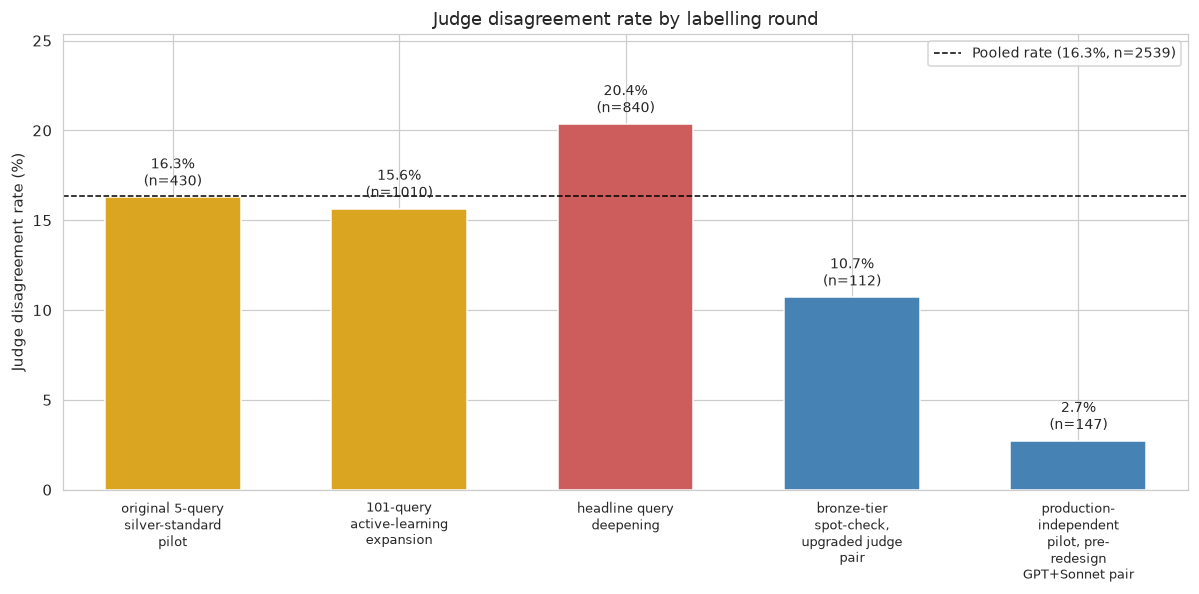

Saved to result/75_silver_standard_disagreement_rate/disagreement_rate_by_round.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

per_round = df[df["round"] != "pooled_all_rounds"].copy()
pooled_row = df[df["round"] == "pooled_all_rounds"].iloc[0]

labels = ["\n".join(textwrap.wrap(d, width=16)) for d in per_round["description"]]
rates = per_round["disagreement_rate"] * 100
ns = per_round["n_candidates"]

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["steelblue" if r < 15 else ("indianred" if r > 18 else "goldenrod") for r in rates]
bars = ax.bar(range(len(per_round)), rates, color=colors, width=0.6)

for i, (bar, n) in enumerate(zip(bars, ns)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{rates.iloc[i]:.1f}%\n(n={n})",
            ha="center", va="bottom", fontsize=9)

ax.axhline(pooled_row["disagreement_rate"] * 100, color="black", linestyle="--", linewidth=1,
           label=f"Pooled rate ({pooled_row['disagreement_rate']*100:.1f}%, n={pooled_row['n_candidates']:.0f})")

ax.set_xticks(range(len(per_round)))
ax.set_xticklabels(labels, fontsize=8.5, multialignment="center")
ax.set_ylabel("Judge disagreement rate (%)")
ax.set_title("Judge disagreement rate by labelling round")
ax.set_ylim(0, max(rates) + 5)
ax.margins(x=0.04)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "disagreement_rate_by_round.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_DIR / 'disagreement_rate_by_round.png'}")